# Model Communication

Notebook implementation and analysis for this project.


<br><br><br><br>




<br><br><br><br>


## Survival Analysis

These notes use customer churn as a concrete case for survival analysis. A binary churn label can hide timing information, while survival analysis keeps track of when churn happens and how risk changes over time.


1. Binary churn labels ignore time-to-event and censoring, leading to information loss and biased models.
2. Not enough information. We must account for survival time (conditioning on having survived so far); tenure alone isn’t enough to compare risk.
3. It means the hazard is very low in that period, so the survival probability stays nearly constant.




<br><br><br><br>


## Communication





### Blog post

I used the Airbnb model as a communication note: explain the task, the data, the model, the results, and the caveats clearly enough for a less technical reader.

A reasonable length for your entire post would be **800 words**. The maximum allowed is **1000 words**.


#### Writing Approach

For the communication piece, I focus on explaining the Airbnb price model in plain language while keeping enough technical detail for a reader to understand the modeling choices.




<br><br>


# Predicting Airbnb Listing Prices in New York City

## Task

In this project, I worked on **Option 2**, which is a regression task based on the New York City Airbnb dataset. The goal is to predict the `price` of an Airbnb listing using the other available features in the dataset.

This is a useful prediction task because Airbnb prices vary a lot across listings, and the dataset includes information such as room type, location, review activity, and avaiprojectility. If a model can predict price reasonably well, it could help estimate what kinds of listings are associated with higher or lower prices.

Since the target variable is continuous, this is a **supervised regression task**. In my analysis, I used **RMSE (root mean squared error)** as the main evaluation metric because it measures prediction error in the same unit as price and penalizes large mistakes more heavily.

## Dataset

I used the Airbnb NYC 2019 dataset loaded from `AB_NYC_2019.csv`. In my notebook, I split the data into training and test sets by first dropping the target column `price` from the feature matrix and then applying `train_test_split` with `test_size=0.3` and `random_state=123`.

```python
import pandas as pd

df = pd.read_csv("AB_NYC_2019.csv")

df.head()

from sklearn.model_selection import train_test_split

X = df.drop("price", axis=1)
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=123
)
```

To explore the target variable, I created a training dataframe and examined the distribution of `price`. In the notebook, I noted that the mean price is **151.53**, the median is **106**, and the maximum is **10,000**. This already suggests that the target is strongly right-skewed and contains extreme outliers.

```python
train_df = X_train.copy()
train_df["price"] = y_train

train_df["price"].describe()
```

As shown in **Figure 1**, the distribution of Airbnb prices is highly right-skewed. Most listings are priced below $200, while a small number of listings have extremely high prices. In the notebook, I noted that these outliers may influence model performance.


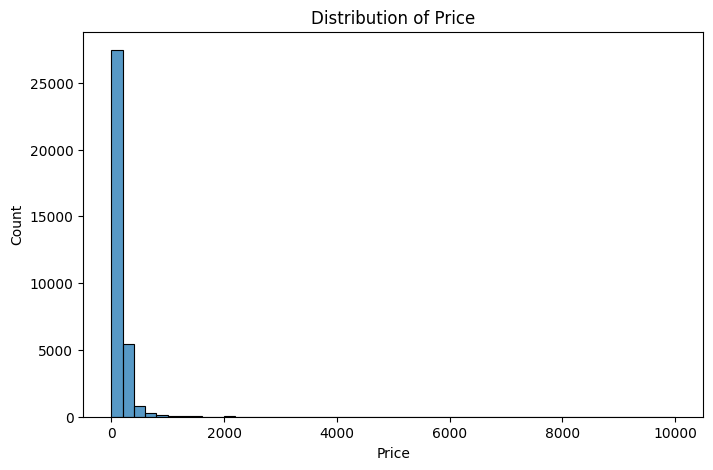

In [4]:
from IPython.display import Image

Image("image1.png")




```python
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(train_df["price"], bins=50)
plt.title("Distribution of Price")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()
```

I also looked at how price differs across room types. As shown in **Figure 2**, entire homes/apartments have the highest median price and the greatest variability, while shared rooms have the lowest median price. This suggests that `room_type` is likely to be an important predictor.


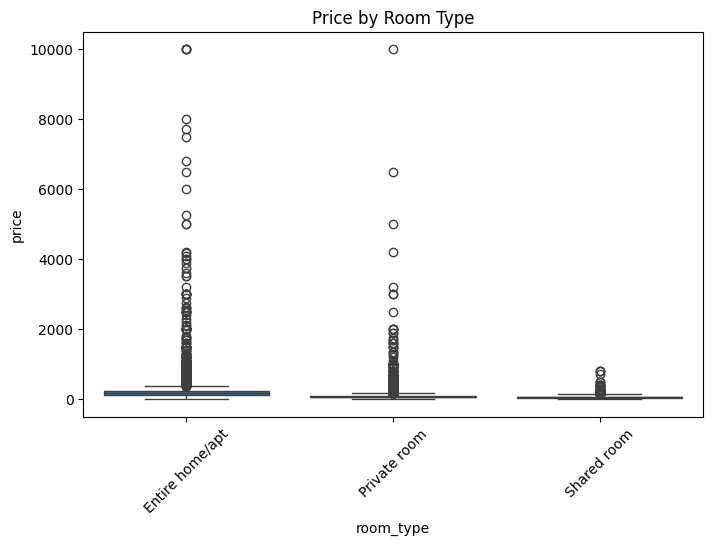

In [5]:
from IPython.display import Image

Image("2.png")



```python
plt.figure(figsize=(8,5))
sns.boxplot(x="room_type", y="price", data=train_df)
plt.title("Price by Room Type")
plt.xticks(rotation=45)
plt.show()
```

In my notebook, I also noted that some review-related variables contain missing values and may require preprocessing before modeling.

## Model

For preprocessing, I divided the features into numerical and categorical groups. In the notebook, I identified the numerical features as:

* `latitude`
* `longitude`
* `minimum_nights`
* `number_of_reviews`
* `reviews_per_month`
* `calculated_host_listings_count`
* `avaiprojectility_365`

and the categorical features as:

* `neighbourhood_group`
* `neighbourhood`
* `room_type`

I also noted that ID and text-based columns were removed.

For categorical features, I used most-frequent imputation followed by one-hot encoding.

```python
categorical_features = [
    "neighbourhood_group",
    "neighbourhood",
    "room_type"
]

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])
```

I first built a **baseline model** using `DummyRegressor`, which always predicts the mean training price. This provides a simple reference point.

```python
from sklearn.dummy import DummyRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

baseline_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DummyRegressor(strategy="mean"))
])

baseline_model.fit(X_train, y_train)
y_pred_base = baseline_model.predict(X_test)

rmse_base = np.sqrt(mean_squared_error(y_test, y_pred_base))

print("Baseline RMSE:", rmse_base)
```

Then I trained a linear regression model and also tuned a Ridge regression model.

```python
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error
import numpy as np

linear_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)

y_pred_linear = linear_model.predict(X_test)

rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))

print("Linear Regression RMSE:", rmse_linear)
```

```python
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

ridge_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Ridge())
])

param_grid = {
    "model__alpha": [0.1, 1.0, 10.0, 100.0]
}

grid_search = GridSearchCV(
    ridge_pipeline,
    param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

grid_search.fit(X_train, y_train)

print("Best alpha:", grid_search.best_params_)
print("Best CV RMSE:", -grid_search.best_score_)
```

I also compared several additional models: **Decision Tree**, **Random Forest**, **Gradient Boosting**, and **KNN**. Later, I performed hyperparameter optimization for **Gradient Boosting** and **Random Forest**, and these tuned ensemble models gave the strongest validation performance.

## Results

The baseline model achieved a **Baseline RMSE of 248.19520555362683**. This gives a reference for how well a model performs if it simply predicts the average price for every listing.

The linear regression model improved on this baseline, with a **Linear Regression RMSE of 234.4130184044142** on the test set. Using cross-validation, the notebook reported:

* **CV RMSE mean: 222.82067511046017**
* **CV RMSE std: 18.805306528460196**

For Ridge regression, the best hyperparameter was:

* **Best alpha: 10.0**
* **Best CV RMSE: 222.5018948689676**

In the notebook, I summarized this as the linear model significantly outperforming the baseline, with Ridge giving very similar performance.

I also evaluated additional non-linear models. Before tuning, the notebook states that none of the non-linear models outperformed the linear model. However, after hyperparameter optimization, the tuned ensemble methods did improve performance:

* **Best GBR CV RMSE: 219.83157493075814**
* **Best RF CV RMSE: 216.0037593103673**

This made the tuned **Random Forest** the best validation model in the notebook.

Finally, I evaluated the best Random Forest model on the test set and obtained:

* **Test RMSE: 226.41319170846404**
* **Test MAE: 65.17920148282717**
* **Test R²: 0.16760772382518718**

These results show that the tuned Random Forest performed better than the baseline and slightly better than the linear approach in validation, although the test RMSE was somewhat higher than the cross-validation RMSE. In the notebook, I described this as **mild optimization bias but generally reasonable generalization performance**.

To interpret the Random Forest model, I plotted the top 15 feature importances. As shown in **Figure 3**, latitude and longitude were among the most important features. In the notebook, I wrote that this suggests micro-location within New York City plays a critical role in determining price.


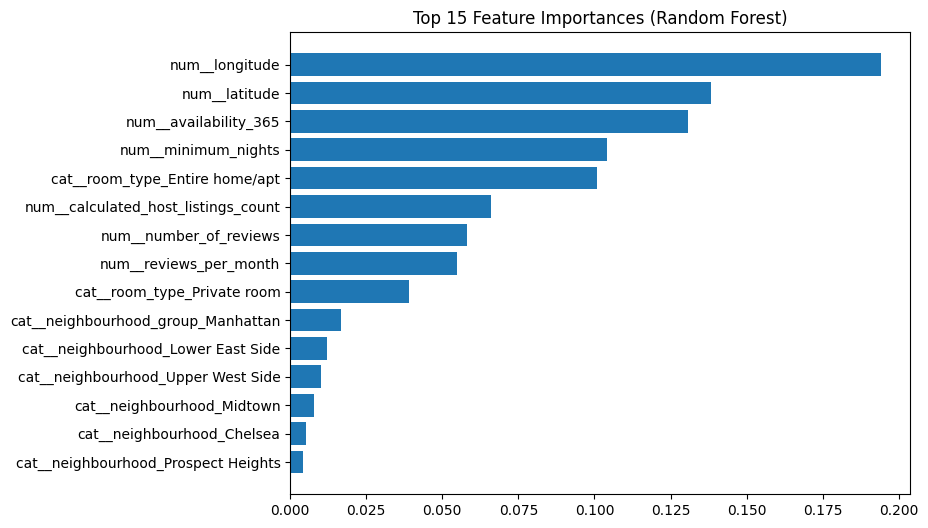

In [6]:
from IPython.display import Image

Image("3.png")



```python
import matplotlib.pyplot as plt

top_features = importance_df.head(15)

plt.figure(figsize=(8,6))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 15 Feature Importances (Random Forest)")
plt.show()
```

I also inspected one individual prediction from the test set. For that example, the **true price was 35**, while the model predicted **68.06395487338183**. In the notebook, I suggested that such an error may be due to unobserved factors such as listing quality or amenities that are not captured in the dataset.

## Caveats

There are several reasons why these results might be misleading or incomplete.

First, the target variable is highly right-skewed and includes extreme outliers. In the notebook, I observed that the maximum price is 10,000 and that the histogram shows a long right tail. This means a small number of unusually expensive listings can strongly affect RMSE and make prediction more difficult.

Second, some review-related variables contain missing values. In the notebook, I noted that these variables may require preprocessing before modeling. If missingness is related to listing behavior in a meaningful way, then simple preprocessing may not fully preserve that information.

Third, the model only uses the structured features available in this dataset. In the notebook, I pointed out that prediction errors may come from unobserved factors such as **listing quality** or **specific amenities**. That means even if two listings look similar in the available columns, their true prices may differ because of information the model never sees.

Fourth, the final Random Forest model had a validation RMSE of about **216.00** but a test RMSE of about **226.41**. In the notebook, I interpreted this as mild optimization bias. This means that choosing the best model after repeated tuning may have made the validation result look slightly better than what we actually get on the unseen test set.

## Conclusion

Overall, this project showed that Airbnb listing price in New York City can be predicted to some extent using structured listing features. The baseline model had an RMSE of about **248**, while linear and tuned tree-based models reduced the error noticeably. The best validation result came from the tuned Random Forest model, and its test RMSE was **226.41**.

The feature importance plot suggests that location-related variables, especially latitude and longitude, are among the most influential predictors. Room type also appeared important during exploratory analysis. At the same time, the relatively modest test **R² of 0.1676** suggests that a large amount of price variation is still not explained by the available features. So while the model captures some useful patterns, it is still limited by the information present in the dataset.




### Effective communication technique

Describe one effective communication technique that you used in your post, or an aspect of the post that you are particularly satisfied with. (Max 3 sentences.)


I structured the post to follow a clear narrative from task → data → model → results → limitations, which makes it easier for readers without machine learning background to follow the reasoning. I also embedded visualizations directly in the text and explicitly referenced them to support key claims, such as the skewed price distribution and feature importance. This helped connect the quantitative results to intuitive explanations grounded in the figures.




<br><br>


## Publication Note

This notebook keeps the communication draft inside the repository rather than linking to a separate public post.




<br><br><br><br>


## Reflection

A few ideas became clearer while working through these projects: preprocessing choices can dominate model quality, validation design matters more than a single score, and explaining a model often exposes assumptions that are easy to miss during implementation.


One key takeaway for me was realizing how important proper evaluation is, especially using cross-validation instead of relying on a single train/test split. Earlier, I would focus mainly on model accuracy, but this project helped me understand issues like overfitting, optimization bias, and why pipelines are necessary to avoid data leakage. Going forward, I would approach personal projects more carefully by building reproducible pipelines, comparing baselines, and interpreting model results rather than just reporting a final score.




<br><br><br><br>
